## 0.Downloading libraries&combining data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

food_path = "../data/raw/food.csv"
nutrient_path = "../data/raw/nutrient.csv"
food_nutrient_path = "../data/raw/food_nutrient.csv"

food = pd.read_csv(food_path)
nutrient = pd.read_csv(nutrient_path)
food_nutrient = pd.read_csv(food_nutrient_path, low_memory=False)

print("food:", food.shape)
print("nutrient:", nutrient.shape)
print("food_nutrient:", food_nutrient.shape)

food: (87990, 5)
nutrient: (477, 5)
food_nutrient: (170469, 11)


## 1.Looking at data

In [5]:
print("food:")
print(food.head(5))
print("nutrient:")
print(nutrient.head(5))
print("food_nutrient:")
print(food_nutrient.head(5))

food:
   fdc_id           data_type            description  food_category_id  \
0  319874         sample_food  HUMMUS, SABRA CLASSIC              16.0   
1  319875  market_acquisition  HUMMUS, SABRA CLASSIC              16.0   
2  319876  market_acquisition  HUMMUS, SABRA CLASSIC              16.0   
3  319877     sub_sample_food                 Hummus              16.0   
4  319878     sub_sample_food                 Hummus              16.0   

  publication_date  
0       2019-04-01  
1       2019-04-01  
2       2019-04-01  
3       2019-04-01  
4       2019-04-01  
nutrient:
     id                               name unit_name  nutrient_nbr   rank
0  2047   Energy (Atwater General Factors)      KCAL         957.0  280.0
1  2048  Energy (Atwater Specific Factors)      KCAL         958.0  290.0
2  1001                             Solids         G         201.0  200.0
3  1002                           Nitrogen         G         202.0  500.0
4  1003                            Protein 

## 2.Leaving only needed info:fat, protein, carbs

In [7]:
nutrient_ids = {
    1008: 'calories',
    1003: 'protein',
    1004: 'fat',
    1005:'carbs'
}

fn_filtered = food_nutrient[food_nutrient['nutrient_id'].isin(nutrient_ids.keys())][['fdc_id','nutrient_id','amount']].copy()
fn_filtered['nutrient_name'] = fn_filtered['nutrient_id'].map(nutrient_ids)

print('Filtered data:', fn_filtered.shape[0])
print(fn_filtered.head())

Filtered data: 6678
    fdc_id  nutrient_id  amount nutrient_name
2   319877         1004    19.0           fat
16  319882         1004    18.7           fat
28  319892         1004    16.6           fat
43  319899         1004    19.1           fat
97  319908         1004    18.2           fat


## 3.Pivotting table: making each nutrient as column

In [8]:
nutrients_pivot = fn_filtered.pivot_table(
    index = 'fdc_id',
    columns = 'nutrient_name',
    values = 'amount',
    aggfunc ='mean'
).reset_index()

print("after pivot: ", nutrients_pivot.shape)
print(nutrients_pivot.head())


after pivot:  (4821, 5)
nutrient_name  fdc_id  calories  carbs   fat  protein
0              319877       NaN    NaN  19.0      NaN
1              319882       NaN    NaN  18.7      NaN
2              319892       NaN    NaN  16.6      NaN
3              319899       NaN    NaN  19.1      NaN
4              319908       NaN    NaN  18.2      NaN


## 4.Combining by names

In [9]:
food_clean = food[['fdc_id', 'description']].copy()

df = food_clean.merge(nutrients_pivot, on='fdc_id', how='inner')
print("result", df.shape)
print(df.head())


result (4821, 6)
   fdc_id description  calories  carbs   fat  protein
0  319877      Hummus       NaN    NaN  19.0      NaN
1  319882      Hummus       NaN    NaN  18.7      NaN
2  319892      Hummus       NaN    NaN  16.6      NaN
3  319899      Hummus       NaN    NaN  19.1      NaN
4  319908      Hummus       NaN    NaN  18.2      NaN


## 5.Cleaning data

In [10]:
print("checking gaps:")
print(df.isnull().sum())
print()

df = df.dropna(subset=['calories', 'protein', 'fat', 'carbs'])
df = df[df['calories'] > 0]

print('After cleaning:', df.shape)

checking gaps:
fdc_id            0
description       0
calories       4686
carbs          4444
fat              65
protein        3411
dtype: int64

After cleaning: (135, 6)


## 6.Statistics by data

In [11]:
print("main statistics:")
print(df[['calories','protein','fat','carbs']].describe().round(2))

main statistics:
       calories  protein     fat   carbs
count    135.00   135.00  135.00  135.00
mean     194.12    11.78    9.37   16.02
std      165.65    12.59   15.15   23.86
min       12.00     0.00    0.00    0.00
25%       52.50     1.13    0.34    2.07
50%      148.00     7.81    2.30    6.02
75%      327.00    19.30   11.50   15.75
max      833.00    79.90   99.10   99.60


## 7.Graphics of distributions of nutrients

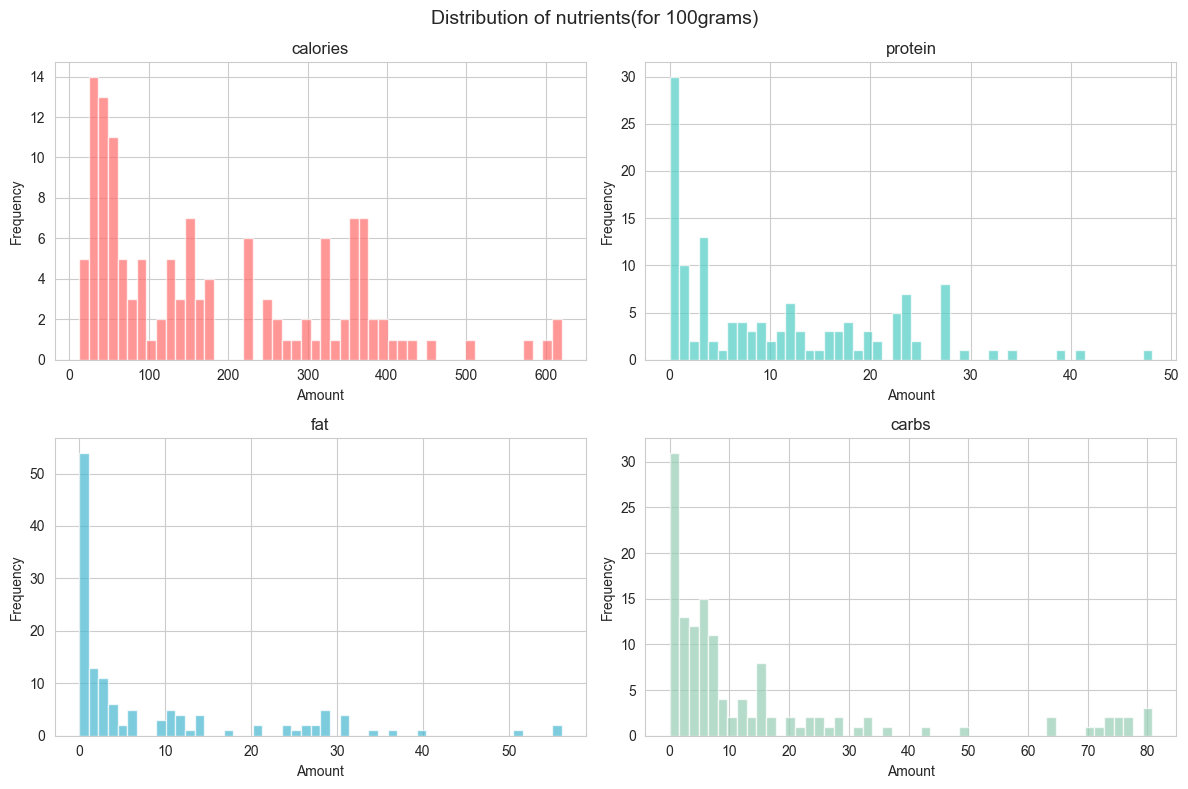

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribution of nutrients(for 100grams)', fontsize=14)

nutrients = ['calories', 'protein', 'fat', 'carbs']
title = ['calories', 'protein', 'fat', 'carbs']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for ax, nutrient, title, color in zip(axes.flat, nutrients, title, colors):
    # Убираем выбросы для графика (топ 1%)
    data = df[nutrient][df[nutrient] < df[nutrient].quantile(0.99)]
    ax.hist(data, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Amount')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 8.Saving cleaned dataset

In [23]:
df = df.rename(columns = {'description' : 'name'})

df[['calories', 'protein', 'fat', 'carbs']] = df[['calories', 'protein', 'fat', 'carbs']].round(2)
df.to_csv('../data/clean/usda_nutrients_clean.csv', index=False)

print('File saved: data/clean/usda_nutrients_clean.csv')
print('Total products :', len(df))
print()
print('Example:')
print(df[['name','calories','protein','fat','carbs']].head(10))

File saved: data/clean/usda_nutrients_clean.csv
Total products : 135

Example:
                                                  name  calories  protein  \
53                                  Hummus, commercial     229.0     7.35   
54   Milk, reduced fat, fluid, 2% milkfat, with add...      50.0     3.35   
55                                Tomatoes, grape, raw      27.0     0.83   
68   Beans, snap, green, canned, regular pack, drai...      21.0     1.04   
87                                       Broccoli, raw      32.0     2.57   
114  Milk, lowfat, fluid, 1% milkfat, with added vi...      43.0     3.38   
142  Milk, nonfat, fluid, with added vitamin A and ...      34.0     3.43   
169   Milk, whole, 3.25% milkfat, with added vitamin D      60.0     3.28   
187                        Frankfurter, beef, unheated     314.0    11.70   
201        Nuts, almonds, dry roasted, with salt added     620.0    20.40   

       fat  carbs  
53   17.10  14.90  
54    1.90   4.91  
55    0.63   